**Feature Scaling in Machine Learning:**

Feature scaling is a preprocessing technique in machine learning that helps bring 
all the features (variables) of your dataset onto a similar scale. It ensures that no 
single feature dominates the learning process because of its larger magnitude.
Different features in your dataset may have values on different scales. For 
example, one feature might range from 0 to 1, while another might range from 0 
to 1000. Feature scaling is used to make sure that these varying scales do not 
affect the performance of machine learning algorithms. Feature scaling involves 
transforming the values of each feature so that they fall within a similar numerical 
range. The common techniques used to do feature scaling are min-max scaling 
and z-score. Feature scaling ensures that all features contribute equally to the 
learning process, preventing some features from having undue influence due to their larger values. It can lead to faster convergence of gradient-based 
optimization algorithms (like gradient descent).

In [ ]:
UPSAMPLING

In [ ]:
import numpy as np
import pandas as pd
data = np.random.randint(10, 100, size=100) 
bins = pd.cut(data, bins=10) 
df = pd.DataFrame({'Value': data, 'Bin': bins})
print(df.sort_values(by='Value'))

    Value             Bin
97     11  (10.912, 19.8]
24     14  (10.912, 19.8]
16     16  (10.912, 19.8]
67     18  (10.912, 19.8]
85     18  (10.912, 19.8]
..    ...             ...
68     95    (90.2, 99.0]
90     96    (90.2, 99.0]
1      96    (90.2, 99.0]
36     98    (90.2, 99.0]
83     99    (90.2, 99.0]

[100 rows x 2 columns]


In [2]:
import numpy as np
import pandas as pd
np.random.seed(123)
n_samples=1000         #records    
class_0_ratio=0.9  #class-0 900 records 90 percent
n_class_0=int(n_samples*class_0_ratio)  #1000*0.9=900
n_class_1=n_samples-n_class_0  #remaining --->1000*0.1=100 

In [3]:
n_class_0,n_class_1

(900, 100)

In [4]:
#create dataframe
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=5,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})
# Generates random numbers from a normal distribution (bell curve).
# loc=0 → mean is 0.
# scale=1 → standard deviation is 1.
# size=n_class_0 → generates 900 numbers (since class 0 has 900 records).
# So, feature_1 and feature_2 are 900 random values each, centered around 0.
# 'target': [0] * n_class_0
# Creates a list of 900 zeros → [0,0,0,...,0].
# This marks all these records as class 0.
class_1=pd.DataFrame({
        'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
        'feature_2':np.random.normal(loc=2,scale=1,size=n_class_1),
        'target':[1]*n_class_1
})

why loc=0 and 2?
Class 0 (target=0) points will cluster around (0,0).

Class 1 (target=1) points will cluster around (2,2)
loc → mean (center) of the normal distribution.

scale → standard deviation (spread / width) of the distribution.

size → how many random numbers to generate.
np.random.normal(loc=0, scale=1, size=5)
Mean = 0

Standard deviation = 1

Generates 5 numbers around 0 (most values close to 0, but can vary).

In [5]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)
# pd.concat([...]) → merges the two DataFrames vertically (row-wise).

In [6]:
print(df.head())
df['target'].value_counts()

   feature_1  feature_2  target
0  -1.085631   5.551302       0
1   0.997345   5.419589       0
2   0.282978   6.815652       0
3  -1.506295   4.747250       0
4  -0.578600   4.707996       0


target
0    900
1    100
Name: count, dtype: int64

In [7]:
df.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


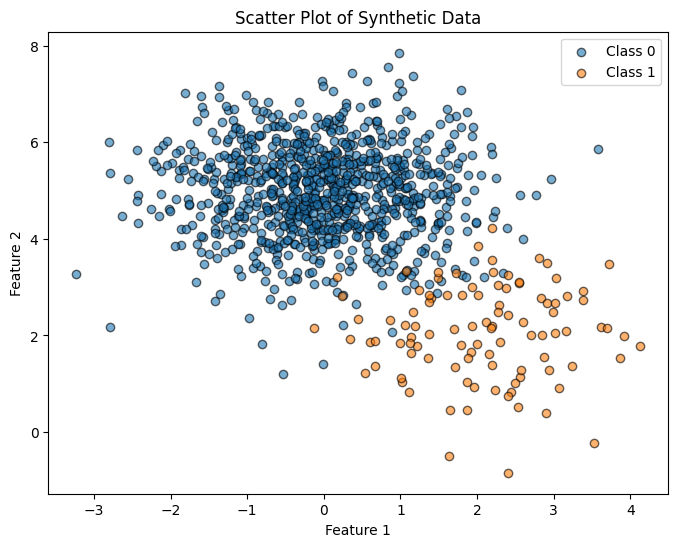

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df[df['target']==0]['feature_1'], df[df['target']==0]['feature_2'],
            alpha=0.6, label="Class 0", edgecolor='k')
plt.scatter(df[df['target']==1]['feature_1'], df[df['target']==1]['feature_2'],
            alpha=0.6, label="Class 1", edgecolor='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Synthetic Data")
plt.legend()
plt.show()

In [9]:
#UPSAMPLING
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [10]:
df_minority.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [11]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True,n_samples=len(df_majority),random_state=42)

In [12]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [13]:
df_upsampled=pd.concat([df_minority_upsampled,df_majority]).reset_index(drop=True)
df_upsampled['target'].value_counts()

target
1    900
0    900
Name: count, dtype: int64

DOWNSAMPLING

In [3]:
import numpy as np
import pandas as pd
np.random.seed(123)
n_samples=1000         #records    
class_0_ratio=0.9  #class-0 900 records 90 percent
n_class_0=int(n_samples*class_0_ratio)  #1000*0.9=900
n_class_1=n_samples-n_class_0  #remaining --->1000*0.1=100 
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=5,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1=pd.DataFrame({
        'feature_1':np.random.normal(loc=2,scale=1,size=n_class_1),
        'feature_2':np.random.normal(loc=2,scale=1,size=n_class_1),
        'target':[1]*n_class_1
})
df=pd.concat([class_0,class_1]).reset_index(drop=True)
print(df.head())
df['target'].value_counts()

   feature_1  feature_2  target
0  -1.085631   5.551302       0
1   0.997345   5.419589       0
2   0.282978   6.815652       0
3  -1.506295   4.747250       0
4  -0.578600   4.707996       0


target
0    900
1    100
Name: count, dtype: int64

In [8]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [11]:
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=True,n_samples=len(df_minority),random_state=42)

In [14]:
df_majority_downsampled.shape

(100, 3)

In [18]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])
print(df_downsampled)
df_downsampled['target'].value_counts()

     feature_1  feature_2  target
900   1.699768   2.139033       1
901   1.367739   2.025577       1
902   1.795683   1.803557       1
903   2.213696   3.312255       1
904   3.033878   3.187417       1
..         ...        ...     ...
201  -0.598105   6.575650       0
269   0.420180   5.570631       0
862  -0.392309   5.446491       0
815  -0.148405   4.542071       0
270  -1.213385   5.675504       0

[200 rows x 3 columns]


target
1    100
0    100
Name: count, dtype: int64

SMOTE(Synthetic Minority OverSampling Technique)
Generating synthetic instances of the minority class by interpolating between existing instances.

In [19]:
from sklearn.datasets import make_classification

In [25]:
x,y=make_classification(n_samples=1000,n_redundant=0,
    n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=42)

In [ ]:
import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)#column wise axis=1
final_df.head()

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0


In [33]:
final_df['target'].value_counts()

target
0    896
1    104
Name: count, dtype: int64

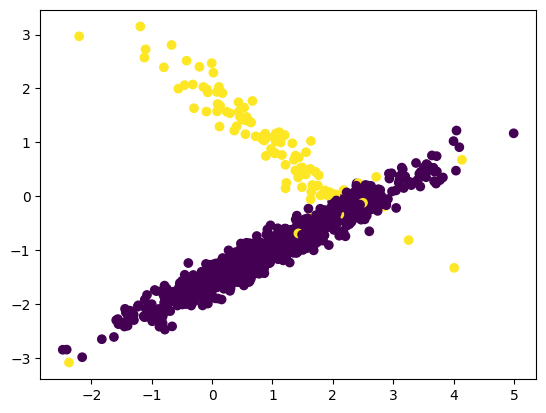

In [34]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [35]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [i

In [48]:
from imblearn.over_sampling import SMOTE
#Transform the dataset
s=SMOTE()
X,Y=s.fit_resample(final_df[['f1','f2']],final_df['target'])

In [49]:
print(X.shape)
Y.shape

(1792, 2)


(1792,)

In [50]:
Y==0

0        True
1        True
2        True
3        True
4        True
        ...  
1787    False
1788    False
1789    False
1790    False
1791    False
Name: target, Length: 1792, dtype: bool

In [51]:
len(Y[Y==0])

896

In [ ]:
len(Y[Y==1])

896

In [54]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(Y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)#column wise axis=1
oversample_df.head()

,f1,f2,target
0,1.073546,-1.101339,0
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,1.951888,-0.270157,0


In [55]:
oversample_df['target'].value_counts()

target
0    896
1    896
Name: count, dtype: int64

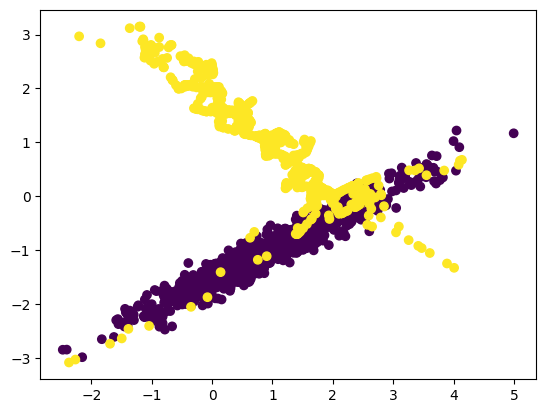

In [53]:
import matplotlib.pyplot as plt
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])